### L1 and L2 Regularization

- informal name "smooting out"

both add regularization tern to the neural network's loss

L1 (Lasso) reg: 

$$
L_{reg} = \frac{1}{N} \sum_{i=1}^{N} \ell(y_i, \hat{y_i}) + \lambda \sum_{j=1}^{M} |w_j|
$$

L2 (Ridge) reg:

$$
L_{reg} = \frac{1}{N} \sum_{i=1}^{N} \ell(y_i, \hat{y_i}) + \lambda \sum_{j=1}^{M} w_j^2
$$


L1 adds the sum of absolute values of all the weights in the network, multiplied by constant called lambda. Lambda is new hyperparameter that we can tune to regularize NN.

Now that we have added the term, the absolute value of weights has become part of the loss. That means the gradient descent algorithm will automatically try to keep the weights small so that the loss can aslo stay small.

Consequently, if the weights are small, then the small change in input tend to result in small change in output and vice-versa because in all the layers we multiplt weights with previous layer out. Hence, small weights cause the model function to change slowly instead of changing it abruptly.

L2 works the same, instead of absolute value it uses suqared values of weights.

L1 and L2 regularization:

-> roll the weights into the neural network’s loss.

-> To minimize the loss, GD tends to keep the weights small.

-> Smaller weights tend to result in a smoother model.

In [9]:
#Lets try L1 reg on Enchidna dataset

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap



In [3]:
def load(filename):
    data = np.loadtxt(filename,skiprows=1,unpack=True).T
    np.random.seed(2025)
    np.random.shuffle(data)
    x_raw = data[:,0:2]
    x_min = x_raw.min(axis=0)
    x_max = x_raw.max(axis=0)
    
    x = (x_raw - x_min) / (x_max - x_min) - 0.5
    y = data[:,2].astype(int).reshape(-1,1)
    return (x,y)

X,Y = load("Datasets/echidna.txt")
X_train,X_validation,X_test = np.split(X,3)
Y_train,Y_validation,Y_test = np.split(Y,3)    

In [4]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import RMSprop

Y_train = to_categorical(Y_train)
Y_validation = to_categorical(Y_validation)

model = Sequential()
model.add(Dense(100,activation="sigmoid",activity_regularizer=l1(0.0004)))
model.add(Dense(30,activation="sigmoid",activity_regularizer=l1(0.0004)))
model.add(Dense(2,activation="softmax"))


2025-10-31 15:30:36.036309: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-10-31 15:30:36.036515: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-31 15:30:36.036537: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-31 15:30:36.036828: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-31 15:30:36.036845: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
model.compile(loss="categorical_crossentropy",
              optimizer=RMSprop(learning_rate=0.001),
              metrics=["accuracy"])



In [8]:
history = model.fit(X_train,Y_train,batch_size=25,
                    epochs=2000,
                    validation_data=(X_validation,Y_validation))


Epoch 1/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.5228 - loss: 1.1074 - val_accuracy: 0.5158 - val_loss: 1.1067
Epoch 2/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5228 - loss: 1.1061 - val_accuracy: 0.5158 - val_loss: 1.1051
Epoch 3/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5228 - loss: 1.1042 - val_accuracy: 0.5158 - val_loss: 1.1029
Epoch 4/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5228 - loss: 1.1018 - val_accuracy: 0.5158 - val_loss: 1.1004
Epoch 5/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5228 - loss: 1.0993 - val_accuracy: 0.5158 - val_loss: 1.0977
Epoch 6/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5228 - loss: 1.0966 - val_accuracy: 0.5158 - val_loss: 1.0950
Epoch 7/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5228 - loss: 1.0938 - val_accuracy: 0.5158 - val_loss: 1.0922
Epoch 8/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5228 - loss: 1.0911 - val_acc

In [10]:
print("\n\nDecision boundries in making ... \n\n\n")

def plot_boundary(model,points):
    RANGE = 0.55
    x_mesh = np.arange(-RANGE,RANGE,0.001)
    y_mesh = np.arange(-RANGE,RANGE,0.001)
    grid_x,grid_y = np.meshgrid(x_mesh,y_mesh)
    grid = np.c_[grid_x.ravel(),grid_y.ravel()]

    classification = model.predict(grid).argmax(axis=1)
    classification_grid = classification.reshape(grid_x.shape)

    BLUE_AND_GREEN = ListedColormap(['#BBBBFF', '#BBFFBB'])
    plt.contourf(grid_x,grid_y,classification_grid,cmap=BLUE_AND_GREEN)


def plot_data_by_label(input_variables,labels,label_selector,symbol):
    points = input_variables[(labels == label_selector).flatten()]
    plt.plot(points[:,0],points[:,1],symbol,markersize=4)


def show(model,x,y,title="Decision Boundary"):
    plot_boundary(model,x)
    plot_data_by_label(x,y,0,'bs')
    plot_data_by_label(x,y,1,'g^')
    plt.gca().axes.xaxis.set_ticklabels([])
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.title(title)
    plt.show()

    



Decision boundries in making ... 





In [11]:
def plot(history):
    plt.clf()
    plt.plot(history.history['loss'],label='Training loss',
             color='blue',linestyle='-')
    plt.plot(history.history['val_loss'],label='Validation set',
             color='green',linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xlim(0,len(history.history['loss']))
    plt.legend(loc='upper right')
    plt.show()


37813/37813 ━━━━━━━━━━━━━━━━━━━━ 56s 1ms/step


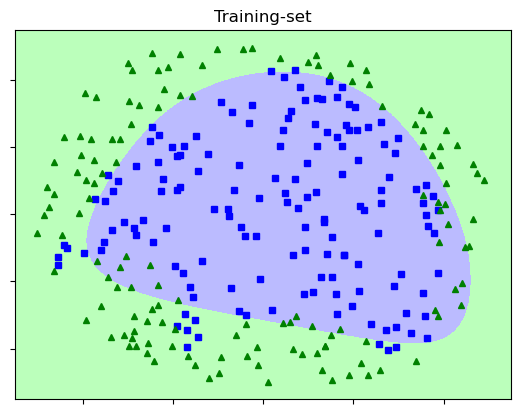

In [14]:
show(model, X_train, np.argmax(Y_train,axis=1),
              title="Training-set")


37813/37813 ━━━━━━━━━━━━━━━━━━━━ 56s 1ms/step


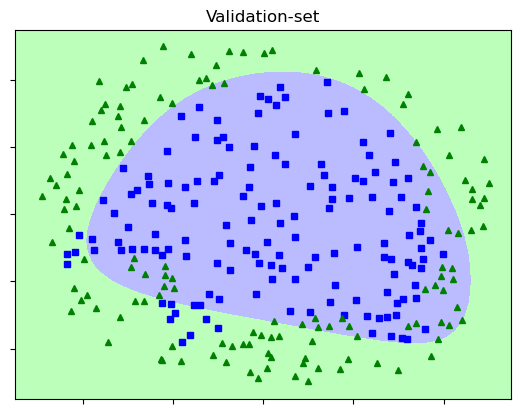

In [15]:
show(model, X_validation, np.argmax(Y_validation,axis=1),
              title="Validation-set")


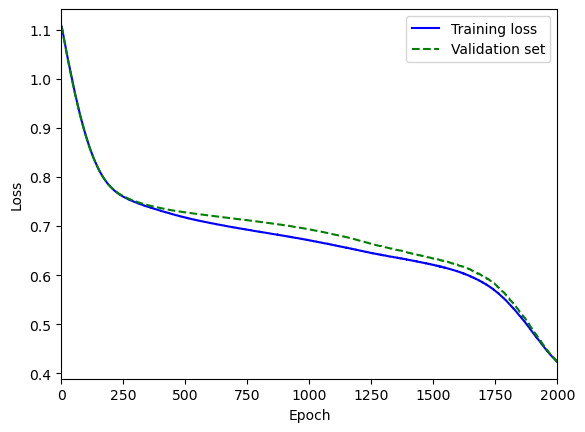

In [16]:
plot(history)

In [29]:
#Train for more epoch approx 30k and you will get approx 90% accuracy (train and validation)

'''
some other techniques are early stopping
dropout
'''


y_pred = np.argmax(model.predict(X_test),axis=1)



9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [33]:
accuracy = np.sum(y_pred == Y_test.flatten())*100.0/len(Y_test)
print(accuracy)


81.40350877192982
